In [27]:
import random
import networkx as nx
import math
from time import time
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt
from networkx.algorithms import community

In [11]:
# SEE COPILOT FOR UNFEASIBLE CENTRALITY AND OTHER MEASURES !!!!



def characterize_network(
    G,
    outfile=None,
    size_density=True,
    degree_stats=True,
    clustering=True,
    shortest_path=True,
    assortativity=True,
    centralities=True,
    communities=True
):

    results = {}

    # ==========================================================
    # 1. Size and density
    # ==========================================================
    if size_density:
        results["N"] = G.number_of_nodes()
        results["L"] = G.number_of_edges()
        results["density"] = nx.density(G)

    # ==========================================================
    # 2. Degree distribution
    # ==========================================================
    if degree_stats:
        degrees = np.array([d for _, d in G.degree()])

        results["k_avg"] = np.mean(degrees)
        results["k_var"] = np.var(degrees)
        results["degrees"] = degrees

    # ==========================================================
    # 3. Clustering coefficient
    # ==========================================================
    if clustering:
        results["clustering"] = nx.average_clustering(G)

    # ==========================================================
    # 4. Average shortest path in GCC
    # ==========================================================
    if shortest_path:
        largest_cc = max(nx.connected_components(G), key=len)
        Gcc = G.subgraph(largest_cc)

        results["gcc_size"] = Gcc.number_of_nodes()
        results["avg_shortest_path"] = nx.average_shortest_path_length(Gcc)

    # ==========================================================
    # 5. Assortativity
    # ==========================================================
    if assortativity:
        results["assortativity"] = nx.degree_assortativity_coefficient(G)

    # ==========================================================
    # 6. Centralities
    # ==========================================================
    if centralities:
        results["degree_centrality"] = nx.degree_centrality(G)

        results["betweenness_centrality"] = nx.betweenness_centrality(G)

        results["eigenvector_centrality"] = nx.eigenvector_centrality(
            G,
            max_iter=1000
        )

    # ==========================================================
    # 7. Communities
    # ==========================================================
    if communities:
        comms = community.louvain_communities(G)

        results["n_communities"] = len(comms)

        results["community_sizes"] = sorted(
            [len(c) for c in comms],
            reverse=True
        )

        results["modularity"] = community.modularity(G, comms)

    # ==========================================================
    # Save to file
    # ==========================================================
    if outfile is not None:

        # Save summary results
        with open(outfile, "w") as f:

            for key, value in results.items():

                if key == "degrees":
                    continue

                if isinstance(value, dict):
                    f.write(f"{key}\n")
                    for k, v in value.items():
                        f.write(f"    {k}: {v}\n")

                else:
                    f.write(f"{key}: {value}\n")

        # Save degree sequence separately
        if degree_stats:

            degrees_outfile = outfile.replace(".txt", "_degrees.txt")

            np.savetxt(
                degrees_outfile,
                degrees,
                fmt="%d"
            )

    return results

############################################
########### function to get <s> ############
############################################

def s_avg(G):
    comps=[]
    G_copy=G.copy()

    for i in range(nx.number_connected_components(G)):
        largest_cluster = max(nx.connected_components(G_copy), key=len)
        comps.append(len(largest_cluster)) 
        G_copy.remove_nodes_from(largest_cluster)

    if len(comps)-1!=0:
        s = (G.number_of_nodes() - comps[0])/(len(comps)-1)
    else:
        s = 0
        
    return s




#######################################################################
###### func to get S, s in function of f for rand, high k attack ######
#######################################################################


def robustness_analysis(
    G,
    outfile=None,
    dq=0.005,
    seed=None
):
    """
    Compute robustness under random failures and targeted attacks.

    Parameters
    ----------
    G : networkx.Graph
        Original graph.
    outfile : str
        Output txt file.
    dq : float
        Step size in q.
    seed : int or None
        Random seed.

    Returns
    -------
    result : dict
        Dictionary containing:
        f, S_rand, s_rand, S_att, s_att
    """

    if seed is not None:
        random.seed(seed)

    N = G.number_of_nodes()

    G_rand = G.copy()
    G_att = G.copy()

    f = []
    S_rand = []
    s_rand = []
    S_att = []
    s_att = []

    removed_rand = 0
    removed_att = 0

    for q in np.arange(0, 1, dq):

        print(f"q = {q:.3f}")

        f.append(q)

        # ======================================================
        # RANDOM REMOVAL
        # ======================================================

        number_remno = int(q * N - removed_rand)

        if number_remno > 0:

            nodes_to_remove = random.sample(
                list(G_rand.nodes()),
                min(number_remno, G_rand.number_of_nodes())
            )

            G_rand.remove_nodes_from(nodes_to_remove)

        removed_rand = N - G_rand.number_of_nodes()

        if G_rand.number_of_nodes() > 0:

            largest_cluster = max(
                nx.connected_components(G_rand),
                key=len
            )

            S_rand.append(
                len(largest_cluster) /
                G_rand.number_of_nodes()
            )

            s_rand.append(s_avg(G_rand))

        else:

            S_rand.append(0)
            s_rand.append(0)

        # ======================================================
        # TARGETED ATTACK
        # ======================================================

        ordered_nodes = [
            node for node, deg in
            sorted(
                G_att.degree,
                key=lambda x: x[1],
                reverse=True
            )
        ]

        number_remno = int(q * N - removed_att)

        if number_remno > 0:

            G_att.remove_nodes_from(
                ordered_nodes[:number_remno]
            )

        removed_att = N - G_att.number_of_nodes()

        if G_att.number_of_nodes() > 0:

            largest_cluster = max(
                nx.connected_components(G_att),
                key=len
            )

            S_att.append(
                len(largest_cluster) /
                G_att.number_of_nodes()
            )

            s_att.append(s_avg(G_att))

        else:

            S_att.append(0)
            s_att.append(0)

    # ==========================================================
    # SAVE TO FILE
    # ==========================================================

    data = np.column_stack([
        f,
        S_rand,
        s_rand,
        S_att,
        s_att
    ])

    np.savetxt(
        outfile,
        data,
        fmt="%.6f",
        header="f S_rand s_rand S_att s_att",
        comments=""
    )

    return {
        "f": np.array(f),
        "S_rand": np.array(S_rand),
        "s_rand": np.array(s_rand),
        "S_att": np.array(S_att),
        "s_att": np.array(s_att)
    }


# TV SHOWS

In [8]:
df = pd.read_csv("./data/facebook_clean_data/tvshow_edges.csv")

G = nx.from_pandas_edgelist(
    df,
    source=df.columns[0],
    target=df.columns[1]
)

In [ ]:
res = characterize_network(G, outfile="./result/TVchar.txt",
    size_density=True,
    degree_stats=True,
    clustering=True,
    shortest_path=True, # circa 1 min
    assortativity=True, # 0s
    centralities=True, # 44s
    communities=True)



In [ ]:
robustness = robustness_analysis(
    G,
    outfile="./result/TVrobustness.txt",
    dq=0.005,
    seed=42
)

q = 0.000
q = 0.005
q = 0.010
q = 0.015
q = 0.020
q = 0.025
q = 0.030
q = 0.035
q = 0.040
q = 0.045
q = 0.050
q = 0.055
q = 0.060
q = 0.065
q = 0.070
q = 0.075
q = 0.080
q = 0.085
q = 0.090
q = 0.095
q = 0.100
q = 0.105
q = 0.110
q = 0.115
q = 0.120
q = 0.125
q = 0.130
q = 0.135
q = 0.140
q = 0.145
q = 0.150
q = 0.155
q = 0.160
q = 0.165
q = 0.170
q = 0.175
q = 0.180
q = 0.185
q = 0.190
q = 0.195
q = 0.200
q = 0.205
q = 0.210
q = 0.215
q = 0.220
q = 0.225
q = 0.230
q = 0.235
q = 0.240
q = 0.245
q = 0.250
q = 0.255
q = 0.260
q = 0.265
q = 0.270
q = 0.275
q = 0.280
q = 0.285
q = 0.290
q = 0.295
q = 0.300
q = 0.305
q = 0.310
q = 0.315
q = 0.320
q = 0.325
q = 0.330
q = 0.335
q = 0.340
q = 0.345
q = 0.350
q = 0.355
q = 0.360
q = 0.365
q = 0.370
q = 0.375
q = 0.380
q = 0.385
q = 0.390
q = 0.395
q = 0.400
q = 0.405
q = 0.410
q = 0.415
q = 0.420
q = 0.425
q = 0.430
q = 0.435
q = 0.440
q = 0.445
q = 0.450
q = 0.455
q = 0.460
q = 0.465
q = 0.470
q = 0.475
q = 0.480
q = 0.485
q = 0.490
q = 0.495


In [15]:

data = np.loadtxt(
    "./result/TVrobustness.txt",
    skiprows=1
)

f = data[:, 0]
S_rand = data[:, 1]
s_rand = data[:, 2]
S_att = data[:, 3]
s_att = data[:, 4]

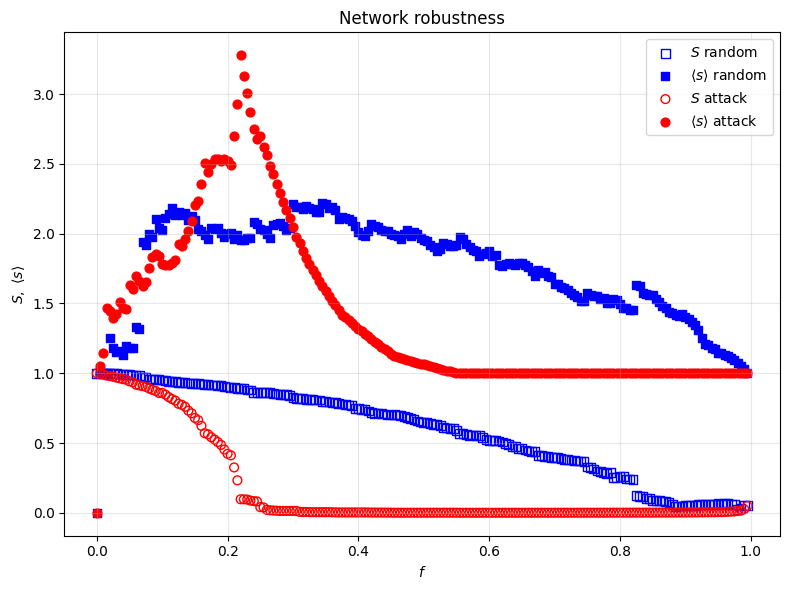

In [17]:

plt.figure(figsize=(8, 6))

# S random: empty blue squares
plt.scatter(
    f, S_rand,
    marker='s',
    facecolors='none',
    edgecolors='blue',
    s=40,
    label=r'$S$ random'
)

# <s> random: filled blue squares
plt.scatter(
    f, s_rand,
    marker='s',
    color='blue',
    s=40,
    label=r'$\langle s \rangle$ random'
)

# S attack: empty red circles
plt.scatter(
    f, S_att,
    marker='o',
    facecolors='none',
    edgecolors='red',
    s=40,
    label=r'$S$ attack'
)

# <s> attack: filled red circles
plt.scatter(
    f, s_att,
    marker='o',
    color='red',
    s=40,
    label=r'$\langle s \rangle$ attack'
)

plt.xlabel(r'$f$')
plt.ylabel(r'$S,\ \langle s \rangle$')
plt.title('Network robustness')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

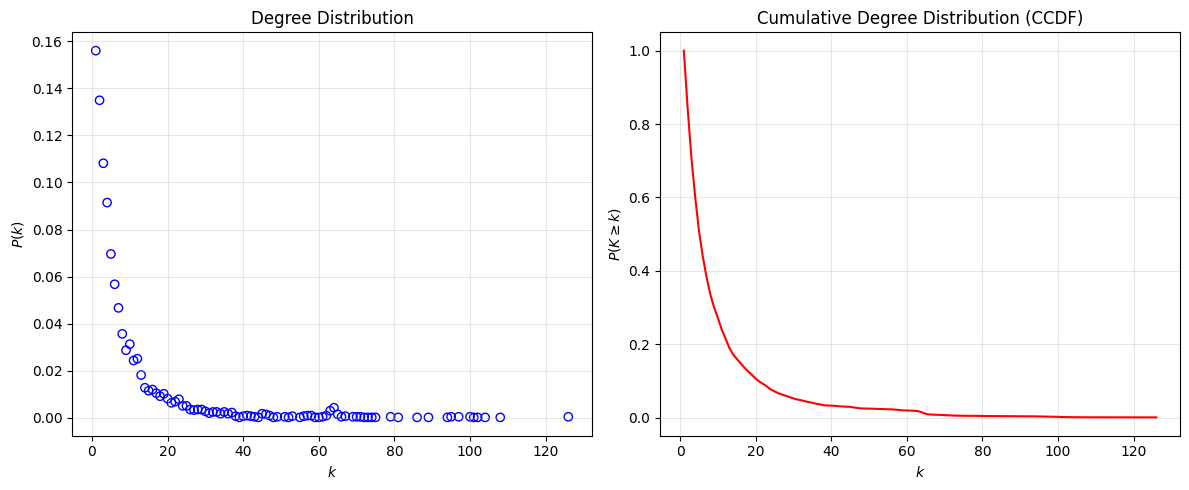

In [ ]:

# Read degree sequence (one degree per line)
degrees = np.loadtxt("result/TVchar_degrees.txt", dtype=int)

N = len(degrees)

# ==========================
# P(k)
# ==========================

k_values, counts = np.unique(degrees, return_counts=True)
Pk = counts / N

# ==========================
# CCDF = P(K >= k)
# ==========================

degrees_sorted = np.sort(degrees)

ccdf = (
    N - np.searchsorted(degrees_sorted, k_values, side="left")
) / N

# ==========================
# Plot
# ==========================

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# P(k)
ax[0].scatter(
    k_values,
    Pk,
    marker="o",
    facecolors="none",
    edgecolors="blue"
)
# ax[0].set_xscale("log")
# ax[0].set_yscale("log")
ax[0].set_xlabel(r"$k$")
ax[0].set_ylabel(r"$P(k)$")
ax[0].set_title("Degree Distribution")
ax[0].grid(True, which="both", alpha=0.3)

# CCDF
ax[1].plot(
    k_values,
    ccdf,
    color="red",
    linewidth=1.5
)
# ax[1].set_xscale("log")
# ax[1].set_yscale("log")
ax[1].set_xlabel(r"$k$")
ax[1].set_ylabel(r"$P(K \geq k)$")
ax[1].set_title("Cumulative Degree Distribution (CCDF)")
ax[1].grid(True, which="both", alpha=0.3)

plt.tight_layout()

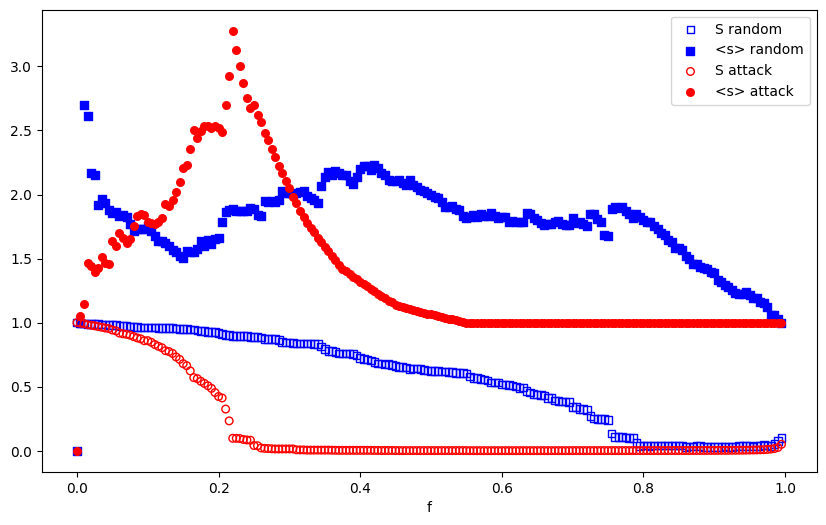

In [ ]:
# plt.figure(1, figsize=(10, 6))
# plt.scatter(f,S_rand,s=30, marker="s",facecolors="none",edgecolors="blue", label="S random")
# plt.scatter(f,s_rand,s=30, marker="s", facecolors="blue", label="<s> random")
# plt.scatter(f,S_att,s=30, marker="o",facecolors="none",edgecolors="red", label="S attack")
# plt.scatter(f,s_att,s=30, marker="o", facecolors="red", label="<s> attack")
# plt.xlabel("f")

# plt.legend()

# plt.show()

# GOVERNMENT

In [21]:
df = pd.read_csv("./data/facebook_clean_data/government_edges.csv")

G = nx.from_pandas_edgelist(
    df,
    source=df.columns[0],
    target=df.columns[1]
)

In [ ]:
res = characterize_network(G, outfile="./result/governmentchar.txt",
    size_density=True,
    degree_stats=True,
    clustering=True,
    shortest_path=False,
    assortativity=True, 
    centralities=False, 
    communities=False)

robustness = robustness_analysis(
    G,
    outfile="government_robustness.txt",
    dq=0.005,
    seed=42
)



q = 0.000
q = 0.005
q = 0.010
q = 0.015
q = 0.020
q = 0.025
q = 0.030
q = 0.035
q = 0.040
q = 0.045
q = 0.050
q = 0.055
q = 0.060
q = 0.065
q = 0.070
q = 0.075
q = 0.080
q = 0.085
q = 0.090
q = 0.095
q = 0.100
q = 0.105
q = 0.110
q = 0.115
q = 0.120
q = 0.125
q = 0.130
q = 0.135
q = 0.140
q = 0.145
q = 0.150
q = 0.155
q = 0.160
q = 0.165
q = 0.170
q = 0.175
q = 0.180
q = 0.185
q = 0.190
q = 0.195
q = 0.200
q = 0.205
q = 0.210
q = 0.215
q = 0.220
q = 0.225
q = 0.230
q = 0.235
q = 0.240
q = 0.245
q = 0.250
q = 0.255
q = 0.260
q = 0.265
q = 0.270
q = 0.275
q = 0.280
q = 0.285
q = 0.290
q = 0.295
q = 0.300
q = 0.305
q = 0.310
q = 0.315
q = 0.320
q = 0.325
q = 0.330
q = 0.335
q = 0.340
q = 0.345
q = 0.350
q = 0.355
q = 0.360
q = 0.365
q = 0.370
q = 0.375
q = 0.380
q = 0.385
q = 0.390
q = 0.395
q = 0.400
q = 0.405
q = 0.410
q = 0.415
q = 0.420
q = 0.425
q = 0.430
q = 0.435
q = 0.440
q = 0.445
q = 0.450
q = 0.455
q = 0.460
q = 0.465
q = 0.470
q = 0.475
q = 0.480
q = 0.485
q = 0.490
q = 0.495


ValueError: could not convert string 'L:' to float64 at row 0, column 1.

In [35]:
data = np.loadtxt(
    "./result/government_robustness.txt",
    skiprows=1
)

f = data[:, 0]
S_rand = data[:, 1]
s_rand = data[:, 2]
S_att = data[:, 3]
s_att = data[:, 4]

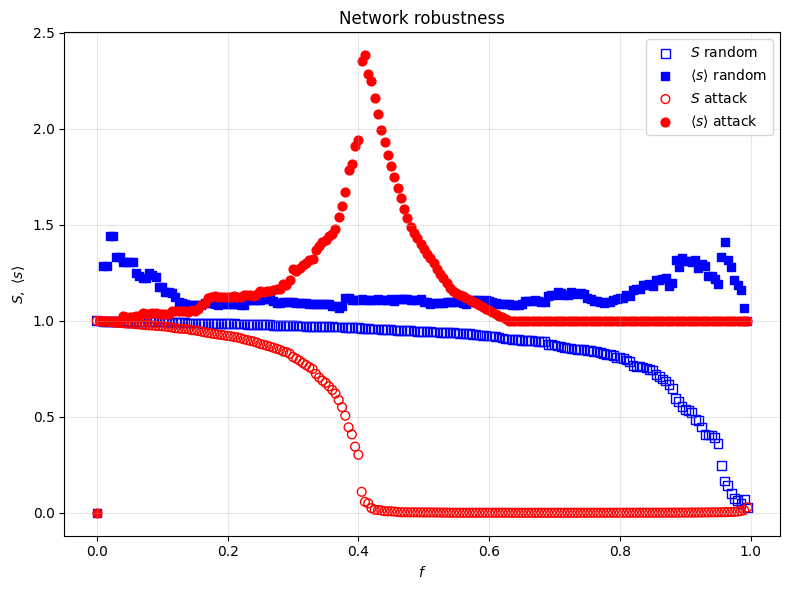

In [36]:

plt.figure(figsize=(8, 6))

# S random: empty blue squares
plt.scatter(
    f, S_rand,
    marker='s',
    facecolors='none',
    edgecolors='blue',
    s=40,
    label=r'$S$ random'
)

# <s> random: filled blue squares
plt.scatter(
    f, s_rand,
    marker='s',
    color='blue',
    s=40,
    label=r'$\langle s \rangle$ random'
)

# S attack: empty red circles
plt.scatter(
    f, S_att,
    marker='o',
    facecolors='none',
    edgecolors='red',
    s=40,
    label=r'$S$ attack'
)

# <s> attack: filled red circles
plt.scatter(
    f, s_att,
    marker='o',
    color='red',
    s=40,
    label=r'$\langle s \rangle$ attack'
)

plt.xlabel(r'$f$')
plt.ylabel(r'$S,\ \langle s \rangle$')
plt.title('Network robustness')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

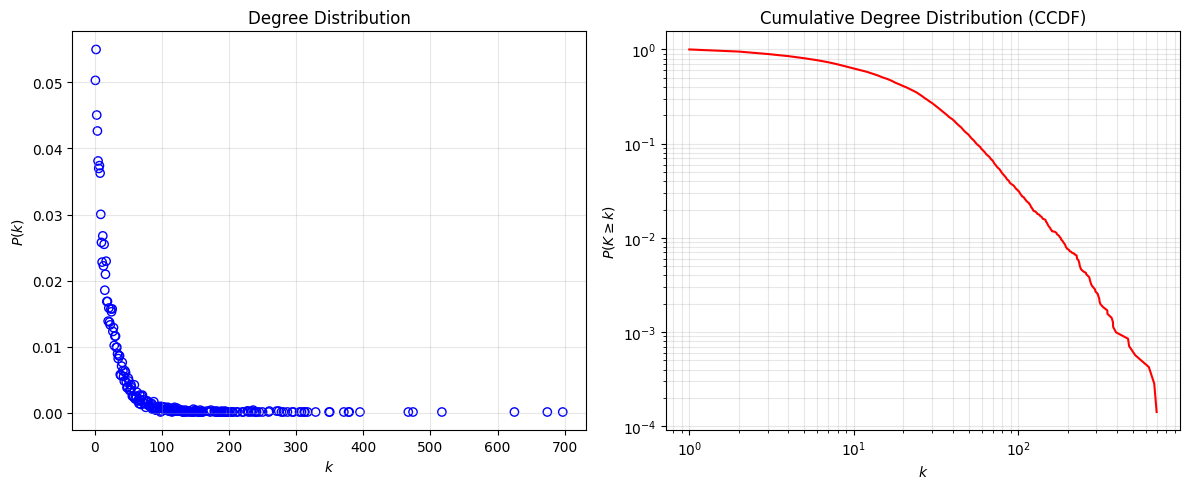

In [38]:

# Read degree sequence (one degree per line)
degrees = np.loadtxt("result/governmentchar_degrees.txt", dtype=int)

N = len(degrees)

# ==========================
# P(k)
# ==========================

k_values, counts = np.unique(degrees, return_counts=True)
Pk = counts / N

# ==========================
# CCDF = P(K >= k)
# ==========================

degrees_sorted = np.sort(degrees)

ccdf = (
    N - np.searchsorted(degrees_sorted, k_values, side="left")
) / N

# ==========================
# Plot
# ==========================

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# P(k)
ax[0].scatter(
    k_values,
    Pk,
    marker="o",
    facecolors="none",
    edgecolors="blue"
)
# ax[0].set_xscale("log")
# ax[0].set_yscale("log")
ax[0].set_xlabel(r"$k$")
ax[0].set_ylabel(r"$P(k)$")
ax[0].set_title("Degree Distribution")
ax[0].grid(True, which="both", alpha=0.3)

# CCDF
ax[1].plot(
    k_values,
    ccdf,
    color="red",
    linewidth=1.5
)
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].set_xlabel(r"$k$")
ax[1].set_ylabel(r"$P(K \geq k)$")
ax[1].set_title("Cumulative Degree Distribution (CCDF)")
ax[1].grid(True, which="both", alpha=0.3)

plt.tight_layout()

# POLITICIAN

In [39]:
df = pd.read_csv("data/facebook_clean_data/politician_edges.csv")

G = nx.from_pandas_edgelist(
    df,
    source=df.columns[0],
    target=df.columns[1]
)

In [ ]:
res = characterize_network(G, outfile="./result/governmentchar.txt",
    size_density=True,
    degree_stats=True,
    clustering=True,
    shortest_path=False,
    assortativity=True, 
    centralities=False, 
    communities=False)

robustness = robustness_analysis(
    G,
    outfile="government_robustness.txt",
    dq=0.005,
    seed=42
)



q = 0.000
q = 0.005
q = 0.010
q = 0.015
q = 0.020
q = 0.025
q = 0.030
q = 0.035
q = 0.040
q = 0.045
q = 0.050
q = 0.055
q = 0.060
q = 0.065
q = 0.070
q = 0.075
q = 0.080
q = 0.085
q = 0.090
q = 0.095
q = 0.100
q = 0.105
q = 0.110
q = 0.115
q = 0.120
q = 0.125
q = 0.130
q = 0.135
q = 0.140
q = 0.145
q = 0.150
q = 0.155
q = 0.160
q = 0.165
q = 0.170
q = 0.175
q = 0.180
q = 0.185
q = 0.190
q = 0.195
q = 0.200
q = 0.205
q = 0.210
q = 0.215
q = 0.220
q = 0.225
q = 0.230
q = 0.235
q = 0.240
q = 0.245
q = 0.250
q = 0.255
q = 0.260
q = 0.265
q = 0.270
q = 0.275
q = 0.280
q = 0.285
q = 0.290
q = 0.295
q = 0.300
q = 0.305
q = 0.310
q = 0.315
q = 0.320
q = 0.325
q = 0.330
q = 0.335
q = 0.340
q = 0.345
q = 0.350
q = 0.355
q = 0.360
q = 0.365
q = 0.370
q = 0.375
q = 0.380
q = 0.385
q = 0.390
q = 0.395
q = 0.400
q = 0.405
q = 0.410
q = 0.415
q = 0.420
q = 0.425
q = 0.430
q = 0.435
q = 0.440
q = 0.445
q = 0.450
q = 0.455
q = 0.460
q = 0.465
q = 0.470
q = 0.475
q = 0.480
q = 0.485
q = 0.490
q = 0.495


ValueError: could not convert string 'L:' to float64 at row 0, column 1.

In [ ]:
data = np.loadtxt(
    "./result/government_robustness.txt",
    skiprows=1
)

f = data[:, 0]
S_rand = data[:, 1]
s_rand = data[:, 2]
S_att = data[:, 3]
s_att = data[:, 4]

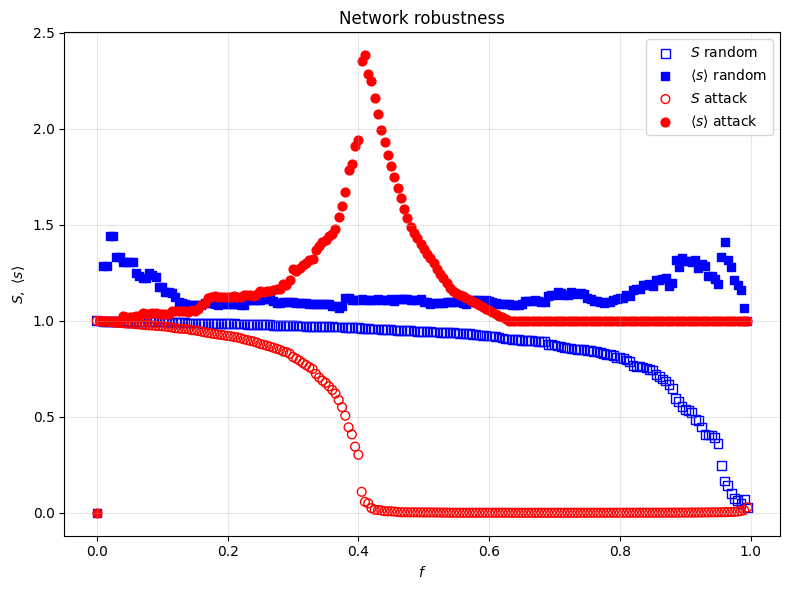

In [ ]:

plt.figure(figsize=(8, 6))

# S random: empty blue squares
plt.scatter(
    f, S_rand,
    marker='s',
    facecolors='none',
    edgecolors='blue',
    s=40,
    label=r'$S$ random'
)

# <s> random: filled blue squares
plt.scatter(
    f, s_rand,
    marker='s',
    color='blue',
    s=40,
    label=r'$\langle s \rangle$ random'
)

# S attack: empty red circles
plt.scatter(
    f, S_att,
    marker='o',
    facecolors='none',
    edgecolors='red',
    s=40,
    label=r'$S$ attack'
)

# <s> attack: filled red circles
plt.scatter(
    f, s_att,
    marker='o',
    color='red',
    s=40,
    label=r'$\langle s \rangle$ attack'
)

plt.xlabel(r'$f$')
plt.ylabel(r'$S,\ \langle s \rangle$')
plt.title('Network robustness')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

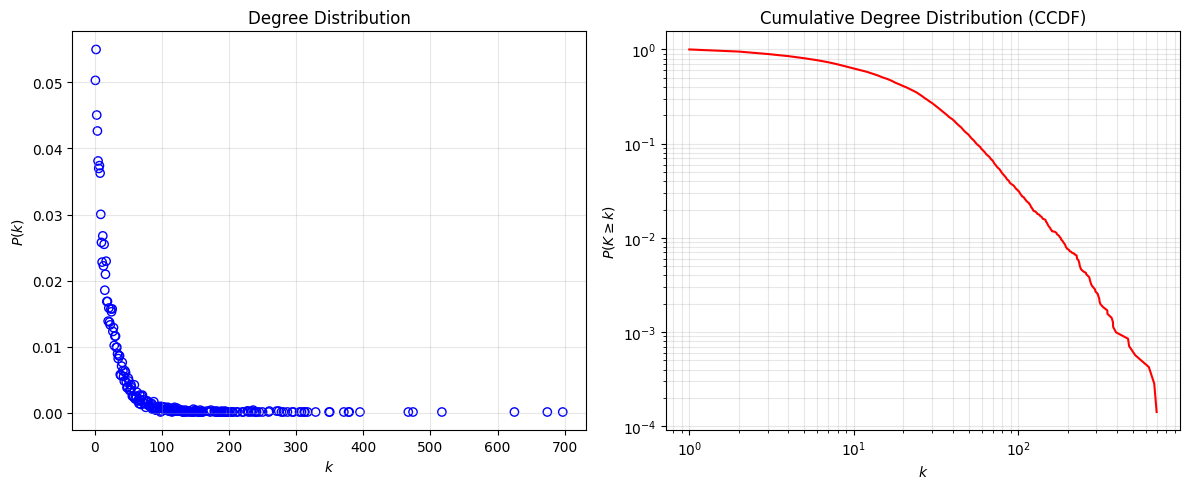

In [ ]:

# Read degree sequence (one degree per line)
degrees = np.loadtxt("result/governmentchar_degrees.txt", dtype=int)

N = len(degrees)

# ==========================
# P(k)
# ==========================

k_values, counts = np.unique(degrees, return_counts=True)
Pk = counts / N

# ==========================
# CCDF = P(K >= k)
# ==========================

degrees_sorted = np.sort(degrees)

ccdf = (
    N - np.searchsorted(degrees_sorted, k_values, side="left")
) / N

# ==========================
# Plot
# ==========================

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# P(k)
ax[0].scatter(
    k_values,
    Pk,
    marker="o",
    facecolors="none",
    edgecolors="blue"
)
# ax[0].set_xscale("log")
# ax[0].set_yscale("log")
ax[0].set_xlabel(r"$k$")
ax[0].set_ylabel(r"$P(k)$")
ax[0].set_title("Degree Distribution")
ax[0].grid(True, which="both", alpha=0.3)

# CCDF
ax[1].plot(
    k_values,
    ccdf,
    color="red",
    linewidth=1.5
)
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].set_xlabel(r"$k$")
ax[1].set_ylabel(r"$P(K \geq k)$")
ax[1].set_title("Cumulative Degree Distribution (CCDF)")
ax[1].grid(True, which="both", alpha=0.3)

plt.tight_layout()

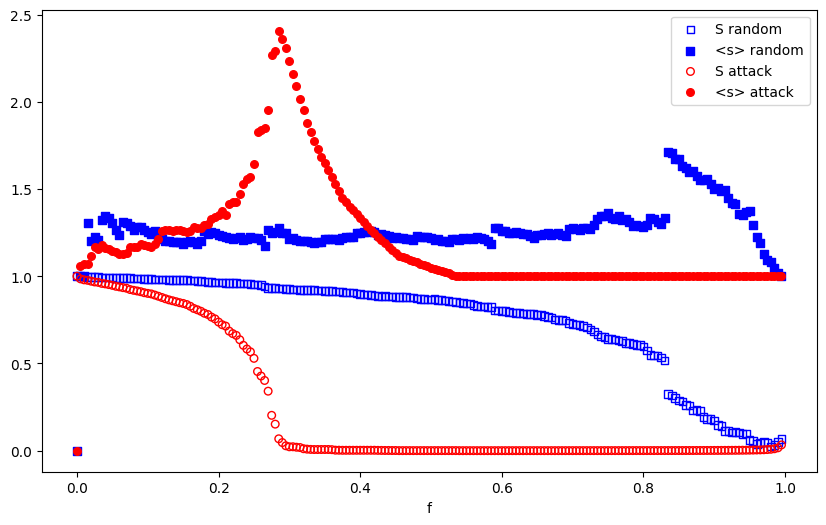

In [12]:
plt.figure(1, figsize=(10, 6))
plt.scatter(f,S_rand,s=30, marker="s",facecolors="none",edgecolors="blue", label="S random")
plt.scatter(f,s_rand,s=30, marker="s", facecolors="blue", label="<s> random")
plt.scatter(f,S_att,s=30, marker="o",facecolors="none",edgecolors="red", label="S attack")
plt.scatter(f,s_att,s=30, marker="o", facecolors="red", label="<s> attack")
plt.xlabel("f")

plt.legend()

plt.show()

# Public figures

In [13]:
df = pd.read_csv("/Users/giole/Desktop/Università/UNIBO/Corsi/ComplexNetworks/Proj/BioNetNodeRemoval/facebook_clean_data/public_figure_edges.csv")

G = nx.from_pandas_edgelist(
    df,
    source=df.columns[0],
    target=df.columns[1]
)

In [14]:
N = G.number_of_nodes()

G_rand = G.copy()
G_att = G.copy()

f = []
S_rand = []
s_rand = []
S_att = []
s_att = []

removed_rand = 0
removed_att = 0

for q in np.arange(0, 1, 0.005):

    print(q)
    f.append(q)

    #### RANDOM REMOVAL ####

    number_remno = int(q * N - removed_rand)

    nodes_to_remove = random.sample(
        list(G_rand.nodes()),
        number_remno
    )

    G_rand.remove_nodes_from(nodes_to_remove)

    removed_rand = N - G_rand.number_of_nodes()

    largest_cluster = max(
        nx.connected_components(G_rand),
        key=len
    )

    S_rand.append(
        len(largest_cluster) / G_rand.number_of_nodes()
    )

    s_rand.append(s_avg(G_rand))

    #### TARGETED ATTACK ####

    ordered_nodes = [
        node for node, deg in
        sorted(
            G_att.degree,
            key=lambda x: x[1],
            reverse=True
        )
    ]

    number_remno = int(q * N - removed_att)

    G_att.remove_nodes_from(
        ordered_nodes[:number_remno]
    )

    removed_att = N - G_att.number_of_nodes()

    largest_cluster = max(nx.connected_components(G_att) , key=len)

    S_att.append(
        len(largest_cluster) / G_att.number_of_nodes()
    )

    s_att.append(s_avg(G_att))

0.0
0.005
0.01
0.015
0.02
0.025
0.03
0.035
0.04
0.045
0.05
0.055
0.06
0.065
0.07
0.075
0.08
0.085
0.09
0.095
0.1
0.105
0.11
0.115
0.12
0.125
0.13
0.135
0.14
0.145
0.15
0.155
0.16
0.165
0.17
0.17500000000000002
0.18
0.185
0.19
0.195
0.2
0.20500000000000002
0.21
0.215
0.22
0.225
0.23
0.23500000000000001
0.24
0.245
0.25
0.255
0.26
0.265
0.27
0.275
0.28
0.28500000000000003
0.29
0.295
0.3
0.305
0.31
0.315
0.32
0.325
0.33
0.335
0.34
0.34500000000000003
0.35000000000000003
0.355
0.36
0.365
0.37
0.375
0.38
0.385
0.39
0.395
0.4
0.405
0.41000000000000003
0.41500000000000004
0.42
0.425
0.43
0.435
0.44
0.445
0.45
0.455
0.46
0.465
0.47000000000000003
0.47500000000000003
0.48
0.485
0.49
0.495
0.5
0.505
0.51
0.515
0.52
0.525
0.53
0.535
0.54
0.545
0.55
0.555
0.56
0.5650000000000001
0.5700000000000001
0.5750000000000001
0.58
0.585
0.59
0.595
0.6
0.605
0.61
0.615
0.62
0.625
0.63
0.635
0.64
0.645
0.65
0.655
0.66
0.665
0.67
0.675
0.68
0.685
0.6900000000000001
0.6950000000000001
0.7000000000000001
0.705
0.

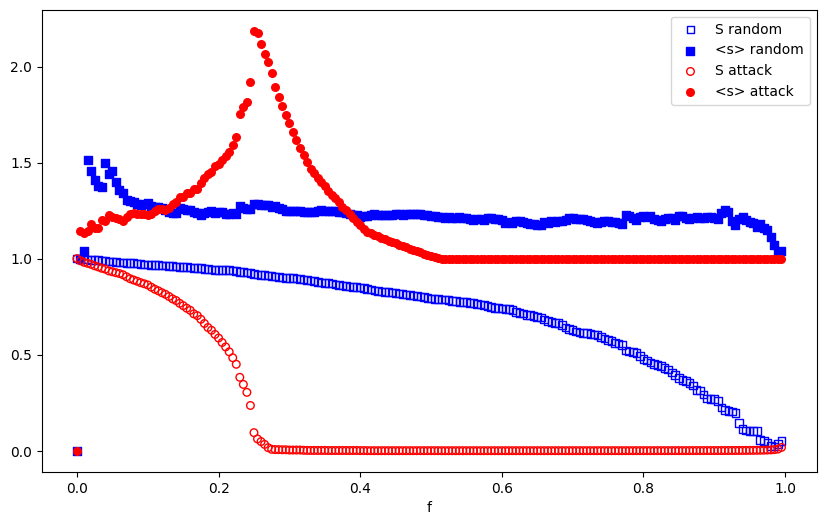

In [15]:
plt.figure(1, figsize=(10, 6))
plt.scatter(f,S_rand,s=30, marker="s",facecolors="none",edgecolors="blue", label="S random")
plt.scatter(f,s_rand,s=30, marker="s", facecolors="blue", label="<s> random")
plt.scatter(f,S_att,s=30, marker="o",facecolors="none",edgecolors="red", label="S attack")
plt.scatter(f,s_att,s=30, marker="o", facecolors="red", label="<s> attack")
plt.xlabel("f")

plt.legend()

plt.show()